# Part 2: Differentiable Communication Systems

This tutorial will guide you through Sionna, from its basic principles to the implementation of a point-to-point link with a 5G NR compliant code and a 3GPP channel model.
You will also learn how to write custom trainable layers by implementing a state of the art neural receiver, and how to train and evaluate end-to-end communication systems.

The tutorial is structured in four notebooks:

- Part I: Getting started with Sionna

- **Part II: Differentiable Communication Systems**

- Part III: Advanced Link-level Simulations

- Part IV: Toward Learned Receivers

The [official documentation](https://nvlabs.github.io/sionna/phy) provides key material on how to use Sionna and how its components are implemented.

* [Imports](#Imports)
* [Gradient Computation Through End-to-end Systems](#Gradient-Computation-Through-End-to-end-Systems)
* [Creating Custom Layers](#Creating-Custom-Layers)
* [Setting up Training Loops](#Setting-up-Training-Loops)

## Imports

In [1]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna as sn
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For plotting
%matplotlib inline
import matplotlib.pyplot as plt

# For saving complex Python data structures efficiently
import pickle

# For the implementation of the neural receiver
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Layer

# Set seed for reproducable results
sn.phy.config.seed = 42

## Gradient Computation Through End-to-end Systems<a class="anchor" id="Gradient-Computation-Through-End-to-end-Systems"></a>

Let's start by setting up a simple communication system that transmit bits modulated as QAM symbols over an AWGN channel.

However, compared to what we have previously done, we now make the constellation
*trainable*. With Sionna, achieving this by assigning trainable points to a
`Constellation` instance.

In [34]:
# Binary source to generate uniform i.i.d. bits
binary_source = sn.phy.mapping.BinarySource()

# 256-QAM constellation
NUM_BITS_PER_SYMBOL = 6
qam_constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)

# Make a trainable constellation initialized with QAM points
trainable_points = tf.Variable(tf.stack([tf.math.real(qam_constellation.points),
                                         tf.math.imag(qam_constellation.points)], axis=0))

constellation = sn.phy.mapping.Constellation("custom",
                                             num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                             points = tf.complex(trainable_points[0], trainable_points[1]),
                                             normalize=True,
                                             center=True)

# Mapper and demapper
mapper = sn.phy.mapping.Mapper(constellation=constellation)
demapper = sn.phy.mapping.Demapper("app", constellation=constellation)

# AWGN channel
awgn_channel = sn.phy.channel.AWGN()

In [35]:
trainable_points

<tf.Variable 'Variable:0' shape=(2, 64) dtype=float32, numpy=
array([[ 0.46291006,  0.46291006,  0.15430336,  0.15430336,  0.46291006,
         0.46291006,  0.15430336,  0.15430336,  0.7715168 ,  0.7715168 ,
         1.0801235 ,  1.0801235 ,  0.7715168 ,  0.7715168 ,  1.0801235 ,
         1.0801235 ,  0.46291006,  0.46291006,  0.15430336,  0.15430336,
         0.46291006,  0.46291006,  0.15430336,  0.15430336,  0.7715168 ,
         0.7715168 ,  1.0801235 ,  1.0801235 ,  0.7715168 ,  0.7715168 ,
         1.0801235 ,  1.0801235 , -0.46291006, -0.46291006, -0.15430336,
        -0.15430336, -0.46291006, -0.46291006, -0.15430336, -0.15430336,
        -0.7715168 , -0.7715168 , -1.0801235 , -1.0801235 , -0.7715168 ,
        -0.7715168 , -1.0801235 , -1.0801235 , -0.46291006, -0.46291006,
        -0.15430336, -0.15430336, -0.46291006, -0.46291006, -0.15430336,
        -0.15430336, -0.7715168 , -0.7715168 , -1.0801235 , -1.0801235 ,
        -0.7715168 , -0.7715168 , -1.0801235 , -1.0801235 ],
 

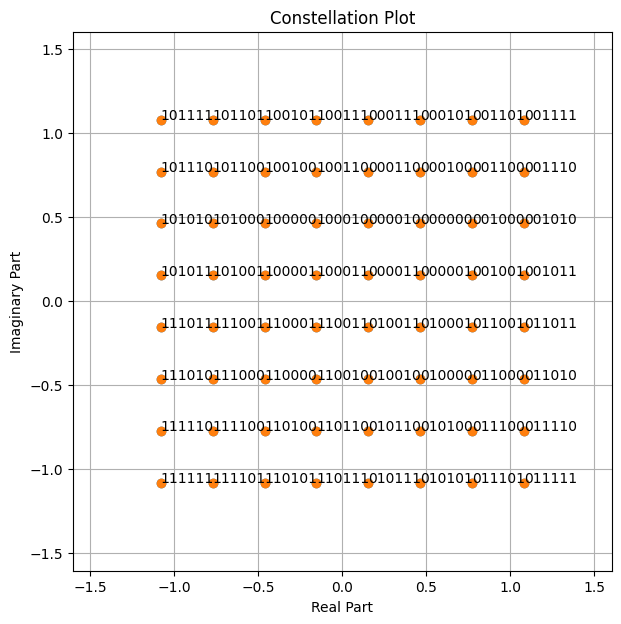

In [36]:
# visualize trainable_points
fig = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL).show()
fig.axes[0].scatter(trainable_points[0], trainable_points[1]);

As we have already seen, we can now easily simulate forward passes through the system we have just setup

In [37]:
BATCH_SIZE = 128 # How many examples are processed by Sionna in parallel
EBN0_DB = 17.0 # Eb/N0 in dB

no = sn.phy.utils.ebnodb2no(ebno_db=EBN0_DB,
                        num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                        coderate=1.0) # Coderate set to 1 as we do uncoded transmission here

bits = binary_source([BATCH_SIZE,
                        1200]) # Blocklength
x = mapper(bits)
y = awgn_channel(x, no)
llr = demapper(y,no)

In [38]:
print(bits.shape)  # 1200 bit长度
print(x.shape)   # 256QAM调制 符号长度为200
print(y.shape)   # 调制后经过加性高斯白噪声信道AWGN信道
print(llr.shape)  # 软判决后 恢复bit长度为1200

(128, 1200)
(128, 200)
(128, 200)
(128, 1200)


In [39]:
y

<tf.Tensor: shape=(128, 200), dtype=complex64, numpy=
array([[ 0.06519204-0.14697915j,  0.1427357 +0.08736604j,
         0.7629933 -0.79746246j, ...,  1.1934619 -0.11876824j,
        -0.44023246-0.73843j   , -1.0715494 +1.1297168j ],
       [ 0.1945879 +0.52001053j,  0.7253152 -1.1145409j ,
        -0.7970009 -0.13189253j, ...,  0.37770787-1.0466815j ,
        -0.38785812+0.10453735j,  0.80653346+1.1413845j ],
       [ 1.06527   -1.0811313j ,  1.1455142 -0.1895988j ,
        -0.15891528+0.41232505j, ...,  0.50585365-0.11319356j,
         1.0663837 +0.4376883j , -0.11110429+0.44335568j],
       ...,
       [ 0.77379656+0.07919517j, -0.47998285+0.13156265j,
        -0.80595684+0.4444585j , ...,  0.57581747-0.10049391j,
        -0.08073954-0.45972118j, -0.76298726+0.53542805j],
       [-0.11554696-0.74201506j,  0.81757295-1.0230553j ,
        -0.48346588-0.4143112j , ..., -1.0919031 -0.15676983j,
        -0.83180666+0.74207294j,  1.11161   -0.51742816j],
       [-0.5440506 -1.115193j  , -

In [40]:
llr

<tf.Tensor: shape=(128, 1200), dtype=float32, numpy=
array([[ -12.099885,   27.27988 , -147.6359  , ...,  132.9665  ,
          27.047895,   37.84397 ],
       [ -36.11624 , -135.75323 ,  -99.603195, ...,  137.29764 ,
         -22.140062,   40.00954 ],
       [-447.20084 ,  458.97665 ,  109.043365, ...,  -32.26865 ,
          36.657185,  -25.009909],
       ...,
       [-259.0229  ,  -14.698918,   29.062414, ...,  -15.179673,
         -30.2224  ,  -42.098873],
       [  21.445944,  241.32661 , -128.9438  , ...,  -18.52052 ,
          34.483295,  -38.758034],
       [ 144.67708 ,  484.26453 ,  -13.579299, ..., -103.82547 ,
         -31.048195,   23.273445]], dtype=float32)>

Just for fun, let's visualize the channel inputs and outputs

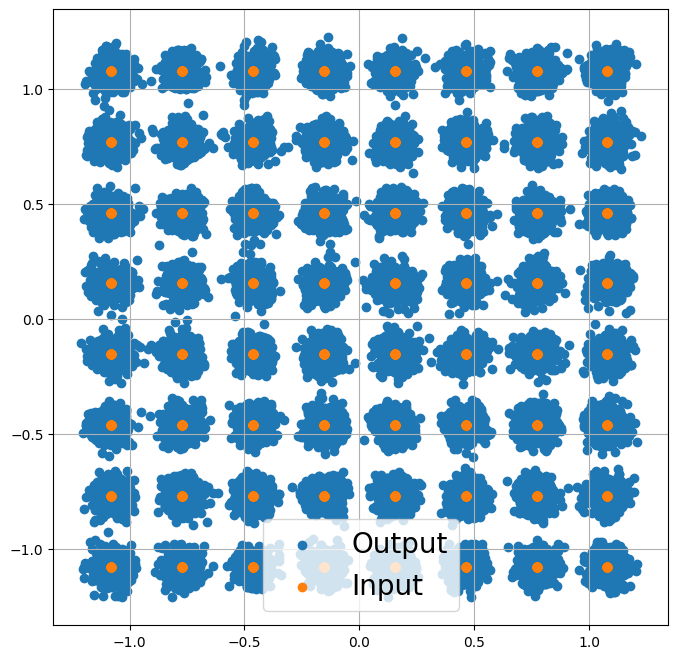

In [41]:
plt.figure(figsize=(8,8))
plt.axes().set_aspect(1.0)
plt.grid(True)
plt.scatter(tf.math.real(y), tf.math.imag(y), label='Output')
plt.scatter(tf.math.real(x), tf.math.imag(x), label='Input')
plt.legend(fontsize=20);

Let's now *optimize* the constellation through *stochastic gradient descent* (SGD). As we will see, this is made very easy by Sionna.

We need to define a *loss function* that we will aim to minimize.

We can see the task of the receiver as jointly solving, for each received symbol, `NUM_BITS_PER_SYMBOL` binary classification problems in order to reconstruct the transmitted bits.
Therefore, a natural choice for the loss function is the *binary cross-entropy* (BCE) applied to each bit and to each received symbol.

AI接收机的作用是对于接受到的符号，对 `NUM_BITS_PER_SYMBOL`进行二进制分类问题，以重建传输的比特。
因此，损失函数是应用于每个比特和每个接收符号的二进制交叉熵（BCE）。---分类问题使用交叉熵损失函数

*Remark:* The LLRs computed by the demapper are *logits* on the transmitted bits, and can therefore be used as-is to compute the BCE without any additional processing.
*Remark 2:* The BCE is closely related to an achieveable information rate for bit-interleaved coded modulation systems [1,2]

注意：
1.软判决本身的运算方式本身就是对传输bit取对数。因此可以按原样用于计算BCE，而无需任何额外处理。

2.对于比特交织编码调制系统来说，BCE与可达信息速率相关性密切

[1] Georg Böcherer, "Principles of Coded Modulation", [available online](http://www.georg-boecherer.de/bocherer2018principles.pdf)

[2] F. Ait Aoudia and J. Hoydis, "End-to-End Learning for OFDM: From Neural Receivers to Pilotless Communication," in IEEE Transactions on Wireless Communications, vol. 21, no. 2, pp. 1049-1063, Feb. 2022, doi: 10.1109/TWC.2021.3101364.

In [42]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

print(f"BCE: {bce(bits, llr)}")

BCE: 0.00010712549556046724


One iteration of SGD consists in three steps:
1. Perform a forward pass through the end-to-end system and compute the loss function
2. Compute the gradient of the loss function with respect to the trainable weights
3. Apply the gradient to the weights

To enable gradient computation, we need to perform the forward pass (step 1) within a `GradientTape`

In [43]:
with tf.GradientTape() as tape:
    bits = binary_source([BATCH_SIZE,
                            1200]) # Blocklength
    mapper.constellation.points = tf.complex(trainable_points[0], trainable_points[1])
    x = mapper(bits)
    y = awgn_channel(x, no)
    llr = demapper(y,no)
    loss = bce(bits, llr)

In [48]:
trainable_points

<tf.Variable 'Variable:0' shape=(2, 64) dtype=float32, numpy=
array([[ 0.46291006,  0.46291006,  0.15430336,  0.15430336,  0.46291006,
         0.46291006,  0.15430336,  0.15430336,  0.7715168 ,  0.7715168 ,
         1.0801235 ,  1.0801235 ,  0.7715168 ,  0.7715168 ,  1.0801235 ,
         1.0801235 ,  0.46291006,  0.46291006,  0.15430336,  0.15430336,
         0.46291006,  0.46291006,  0.15430336,  0.15430336,  0.7715168 ,
         0.7715168 ,  1.0801235 ,  1.0801235 ,  0.7715168 ,  0.7715168 ,
         1.0801235 ,  1.0801235 , -0.46291006, -0.46291006, -0.15430336,
        -0.15430336, -0.46291006, -0.46291006, -0.15430336, -0.15430336,
        -0.7715168 , -0.7715168 , -1.0801235 , -1.0801235 , -0.7715168 ,
        -0.7715168 , -1.0801235 , -1.0801235 , -0.46291006, -0.46291006,
        -0.15430336, -0.15430336, -0.46291006, -0.46291006, -0.15430336,
        -0.15430336, -0.7715168 , -0.7715168 , -1.0801235 , -1.0801235 ,
        -0.7715168 , -0.7715168 , -1.0801235 , -1.0801235 ],
 

Using the ``GradientTape``, computing the gradient is done as follows

In [49]:
gradient = tape.gradient(loss, [trainable_points])

`gradient` is a list of tensors, each tensor corresponding to a trainable variable of our model.

For this model, we only have a single trainable tensor: The constellation of shape [`2`, `2^NUM_BITS_PER_SYMBOL`], the first dimension corresponding to the real and imaginary components of the constellation points.

*Remark:* It is important to notice that the gradient computation was performed *through the demapper and channel*, which are conventional non-trainable algorithms implemented as *differentiable* Sionna blocks. This key feature of Sionna enables the training of end-to-end communication systems that combine both trainable and conventional and/or non-trainable signal processing algorithms.

梯度是一个张量列表，每个张量对应于我们模型的一个可训练变量。

对于这个模型，我们只有一个可训练的张量：形状为[2，2^NUM_BITS_PER_SYMBOL]的星座，第一维对应于星座点的实部和虚部。

值得注意的是，梯度计算是通过判决器和信道进行的，这是作为可微的Sionna Block的特性，这种关键性质保证了Sionna平台的端到端通信系统的可训练性。

In [50]:
for g in gradient:
    print(g.shape)

(2, 64)


In [51]:
g

<tf.Tensor: shape=(2, 64), dtype=float32, numpy=
array([[-1.33469832e-04,  1.25705410e-04, -2.65491690e-04,
         2.60336878e-04, -5.09362435e-04,  1.66070546e-04,
         2.27599419e-04,  1.38090363e-05,  2.96214363e-04,
         2.46456504e-04, -2.42403490e-04, -1.89590370e-04,
         3.69443260e-05,  1.87513069e-05,  4.49268155e-05,
         3.76604330e-05,  7.40521136e-06, -4.05126775e-06,
        -3.92715883e-05, -3.19046012e-05,  2.45609735e-05,
         1.82324147e-04,  3.52007592e-05, -8.92930984e-05,
         2.29085235e-05,  2.36320993e-04,  5.44776085e-05,
        -1.70048879e-04,  4.59648982e-05, -1.39745447e-04,
         4.62439493e-06,  1.66140853e-05, -1.02601480e-04,
        -4.24171565e-04, -4.07137341e-05, -9.22566978e-05,
        -6.98231815e-05, -1.57855407e-04,  6.88016007e-05,
        -8.95496632e-05, -4.93281259e-05, -3.11552460e-04,
        -1.16280120e-04,  5.18179382e-04, -1.98610083e-04,
         1.07148910e-04, -1.28996806e-04, -7.94741645e-05,
       

Applying the gradient (third step) is performed using an *optimizer*. [Many optimizers are available as part of TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers), and we use in this notebook ``Adam``.

In [52]:
optimizer = tf.keras.optimizers.Adam(1e-2)

Using the optimizer, the gradients can be applied to the trainable weights to update them

In [53]:
optimizer.apply_gradients(zip(gradient, tape.watched_variables()));

In [54]:
trainable_points
# 这里可以注意到trainable_points值已经根据Adam优化器（即梯度下降）自动变化了
# 梯度更新后的trainable_points值是Adam前（梯度下降前）的trainable_points值 - loss
# 所以可以在下图中展示出了更新前后的不同

<tf.Variable 'Variable:0' shape=(2, 64) dtype=float32, numpy=
array([[ 0.47267854,  0.45315552,  0.16418558,  0.14442344,  0.4728483 ,
         0.453097  ,  0.14444046,  0.14616671,  0.7616225 ,  0.7616435 ,
         1.0899947 ,  1.0899594 ,  0.7623053 ,  0.7629599 ,  1.0707812 ,
         1.0708983 ,  0.45590258,  0.4685262 ,  0.16355807,  0.16340151,
         0.45405078,  0.4530806 ,  0.14512773,  0.16396126,  0.7627298 ,
         0.7616489 ,  1.0706723 ,  1.0899409 ,  0.76216054,  0.7812955 ,
         1.0741848 ,  1.0717226 , -0.4532091 , -0.45298412, -0.14502415,
        -0.14463483, -0.4533434 , -0.45310652, -0.16386387, -0.14464451,
        -0.7621193 , -0.76161736, -1.0703883 , -1.0900629 , -0.76167357,
        -0.7812301 , -1.0703629 , -1.0705063 , -0.47281525, -0.45334303,
        -0.14437802, -0.1451481 , -0.47279963, -0.45335874, -0.14438154,
        -0.1451006 , -0.7617733 , -0.7618632 , -1.0704933 , -1.0704185 ,
        -0.76171756, -0.7617582 , -1.071072  , -1.0705506 ],
 

Let's compare the constellation before and after the gradient application

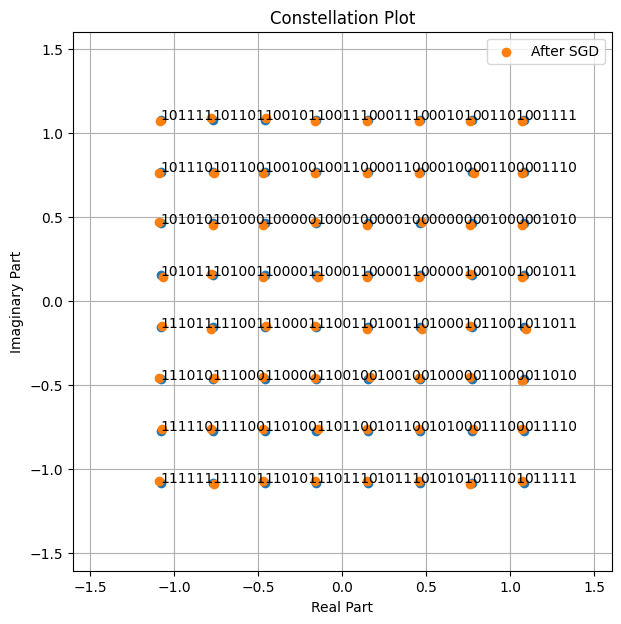

In [21]:
fig = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL).show()
fig.axes[0].scatter(trainable_points[0], trainable_points[1], label='After SGD')
fig.axes[0].legend();

The SGD step has led to slight change in the position of the constellation points. Training of a communication system using SGD consists in looping over such SGD steps until a stop criterion is met.

SGD步骤导致星座点的位置略有变化。使用SGD的通信系统的训练包括循环这些SGD步骤，直到满足停止标准。



## Creating Custom Layers<a class="anchor" id="Creating-Custom-Layers"></a>

Custom trainable (or not trainable) algorithms can be implemented as [Keras layers](https://keras.io/api/layers/) or Sionna blocks. All Sionna components, such as the mapper, demapper, channel... are implemented as Sionna blocks.

所有的Sionna的通信模块：mapper, demapper, channel...都是以Sionna Block的模式组织起来的，Sionna Block与TF/Keras layers是可以拼接的，这也是Sionna平台构造可微分的端到端通信系统的基础。

To illustrate how this can be done, the next cell implements a simple neural network-based demapper which consists of three dense layers.

In [22]:
class NeuralDemapper(Layer): # Inherits from Keras Layer

    def __init__(self):
        super().__init__()

        # The three dense layers that form the custom trainable neural network-based demapper
        self.dense_1 = Dense(64, 'relu')
        self.dense_2 = Dense(64, 'relu')
        self.dense_3 = Dense(NUM_BITS_PER_SYMBOL, None) # The last layer has no activation and therefore outputs logits, i.e., LLRs

    def call(self, y):
        # 这个过程相当于，我们希望输入一个y（调制后的加噪的符号序列），能通过神经网络参数的运算以后，输出正确的解调llr。
        # 而如何训练和学习这个神经网络的参数，是算法设计和学习的过程。

        # y : complex-valued with shape [batch size, block length]
        # y is first mapped to a real-valued tensor with shape
        #  [batch size, block length, 2]
        # where the last dimension consists of the real and imaginary components
        # The dense layers operate on the last dimension, and treat the inner dimensions as batch dimensions, i.e.,
        # all the received symbols are independently processed.
        print('y', y.shape)  # (128, 200)
        nn_input = tf.stack([tf.math.real(y), tf.math.imag(y)], axis=-1)
        print('nn_input', nn_input.shape) # (128, 200, 2)
        z = self.dense_1(nn_input)
        print('z1', z.shape) # (128, 200, 64)
        z = self.dense_2(z)
        print('z2', z.shape) # (128, 200, 64)
        z = self.dense_3(z) # [batch size, number of symbols per block, number of bits per symbol]
        print('z3', z.shape) # (128, 200, 6)
        llr = tf.reshape(z, [tf.shape(y)[0], -1]) # [batch size, number of bits per block]
        print('llr', llr.shape) # (128, 1200)  ---相当于把z3的后两维合并了 200*6=1200
        return llr



In [23]:
print(y)
nn_input = tf.stack([tf.math.real(y), tf.math.imag(y)], axis=-1)
# 相当于把长度为200的复数转变为了200*2的实数矩阵
print(nn_input)

tf.Tensor(
[[-0.5196399 -0.45719057j -0.5062489 -0.7638j     -0.18387416-0.18530428j
  ... -0.7127049 +1.0338075j   0.8020887 -0.7155048j
   0.1590702 -0.47108924j]
 [ 0.71366113-0.46126783j -0.4287927 +0.13598245j -0.8077692 -0.47365984j
  ... -0.19591074+0.79704297j -1.1299765 +0.45075238j
   0.11394911+1.0774666j ]
 [ 0.45641124+0.2906235j  -0.7352966 +0.15725948j  0.462535  +0.4433723j
  ...  0.4856937 +0.802932j    0.45530084-0.45647028j
  -0.4235441 -0.4384353j ]
 ...
 [-1.1001253 -1.0704801j  -1.0879667 +0.56200606j -0.7739419 -1.1313355j
  ... -1.1191738 -0.48492736j  0.48510438-0.39062122j
  -0.764698  +0.79455936j]
 [ 0.72050786-1.1132041j   0.15042426-0.10332103j  0.04426954-0.10485697j
  ... -1.0684892 +0.38539928j -0.14795932-0.47891298j
   0.50173515+0.49582985j]
 [-0.7105158 -0.74590623j -0.17445023+0.4054078j   0.49955928+0.7417157j
  ... -1.141659  +0.14205807j  1.1102861 +0.19623211j
   0.4833259 -0.18496858j]], shape=(128, 200), dtype=complex64)
tf.Tensor(
[[[-0.5196

A custom Keras layer is used as any other Sionna layer, and therefore integration to a Sionna-based communication is straightforward.

The following model uses the neural demapper instead of the conventional demapper. It takes at initialization a parameter that indicates if the model is intantiated to be trained or evaluated. When instantiated to be trained, the loss function is returned. Otherwise, the transmitted bits and LLRs are returned.

In [24]:
class End2EndSystem(Model): # Inherits from Keras Model

    def __init__(self, training):

        super().__init__() # Must call the Keras model initializer

        qam_constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)

        self.points = tf.Variable(tf.stack([tf.math.real(qam_constellation.points),
                                            tf.math.imag(qam_constellation.points)], axis=0))

        self.constellation = sn.phy.mapping.Constellation("custom",
                                                    num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                                    points = tf.complex(self.points[0], self.points[1]),
                                                    normalize=True,
                                                    center=True)
        self.mapper = sn.phy.mapping.Mapper(constellation=self.constellation)
        self.demapper = NeuralDemapper() # Intantiate the NeuralDemapper custom layer as any other
        self.binary_source = sn.phy.mapping.BinarySource()
        self.awgn_channel = sn.phy.channel.AWGN()
        self.bce = tf.keras.losses.BinaryCrossentropy(from_logits=True) # Loss function
        self.training = training

    @tf.function(jit_compile=True) # Enable graph execution to speed things up
    def __call__(self, batch_size, ebno_db):

        # no channel coding used; we set coderate=1.0
        no = sn.phy.utils.ebnodb2no(ebno_db,
                                num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                coderate=1.0)
        bits = self.binary_source([batch_size, 1200]) # Blocklength set to 1200 bits

        # Assign points to constellation
        self.mapper.constellation.points = tf.complex(self.points[0], self.points[1])

        x = self.mapper(bits)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y)  # Call the NeuralDemapper custom layer as any other
        if self.training:
            loss = self.bce(bits, llr)
            return loss
        else:
            return bits, llr

When a model that includes a neural network is created, the neural network weights are randomly initialized typically leading to very poor performance.

To see this, the following cell benchmarks the previously defined untrained model against a conventional baseline.

当创建包含神经网络的模型时，神经网络权重被随机初始化，通常会导致性能非常差。

为了看到这一点，以下单元格将之前定义的未经训练的模型与传统基线进行基准测试

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 2.5964e-02 | 1.0000e+00 |        3988 |      153600 |          128 |         128 |         2.2 |reached target block errors
   10.526 | 2.1296e-02 | 1.0000e+00 |        3271 |      153600 |          128 |         128 |         0.2 |reached target block errors
   11.053 | 1.6087e-02 | 1.0000e+00 |        2471 |      153600 |          128 |         128 |         0.2 |reached target block errors
   11.579 | 1.2728e-02 | 1.0000e+00 |        1955 |      153600 |          128 |         128 |         0.2 |reached target block errors
   12.105 | 8.6003e-03 | 1.0000e+00 |        1321 |      153600 |          128 |         128 |         0.2 |reached target block errors
   12.632 | 6.6081e-03 | 1.0000e+00 |        1015 |      153600 |

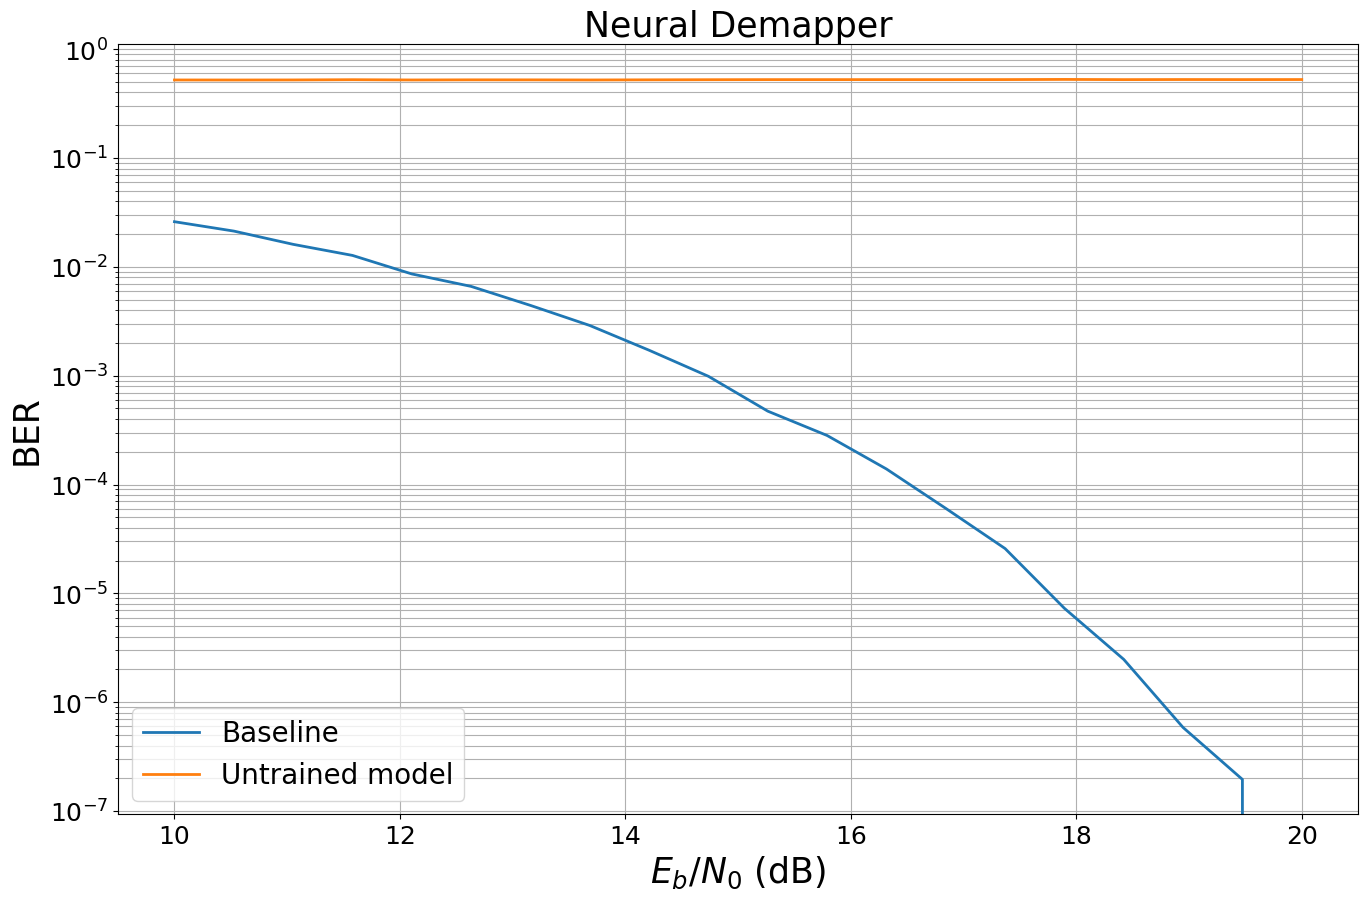

In [25]:
EBN0_DB_MIN = 10.0
EBN0_DB_MAX = 20.0


###############################
# Baseline
###############################

class Baseline(Model): # Inherits from Keras Model

    def __init__(self):

        super().__init__() # Must call the Keras model initializer

        self.constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)
        self.mapper = sn.phy.mapping.Mapper(constellation=self.constellation)
        self.demapper = sn.phy.mapping.Demapper("app", constellation=self.constellation)
        self.binary_source = sn.phy.mapping.BinarySource()
        self.awgn_channel = sn.phy.channel.AWGN()

    @tf.function # Enable graph execution to speed things up
    def __call__(self, batch_size, ebno_db):

        # no channel coding used; we set coderate=1.0
        no = sn.phy.utils.ebnodb2no(ebno_db,
                                num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                coderate=1.0)
        bits = self.binary_source([batch_size, 1200]) # Blocklength set to 1200 bits
        x = self.mapper(bits)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y,no)
        return bits, llr

###############################
# Benchmarking
###############################

baseline = Baseline()
model = End2EndSystem(False)
ber_plots = sn.phy.utils.PlotBER("Neural Demapper")
ber_plots.simulate(baseline,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occured
                  legend="Baseline",
                  soft_estimates=True,
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=False);
ber_plots.simulate(model,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occured
                  legend="Untrained model",
                  soft_estimates=True,
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=True);

## Setting up Training Loops <a class="anchor" id="Setting-up-Training-Loops"></a>

Training of end-to-end communication systems consists in iterating over SGD steps.

The next cell implements a training loop of `NUM_TRAINING_ITERATIONS` iterations.
The training SNR is set to $E_b/N_0 = 15$ dB.

At each iteration:
- A forward pass through the end-to-end system is performed within a gradient tape
- The gradients are computed using the gradient tape, and applied using the Adam optimizer
- The estimated loss is periodically printed to follow the progress of training

In [30]:
# Number of iterations used for training
NUM_TRAINING_ITERATIONS = 1000

# Instantiating the end-to-end model for training
model_train = End2EndSystem(training=True)

# Adam optimizer (SGD variant)
optimizer = tf.keras.optimizers.Adam()

# Training loop
for i in range(NUM_TRAINING_ITERATIONS):
    print('i_ITERATIONS', i)
    # Forward pass
    with tf.GradientTape() as tape:
        loss = model_train(BATCH_SIZE, 15.0) # The model is assumed to return the BMD rate
    # Computing and applying gradients
    grads = tape.gradient(loss, model_train.trainable_weights)
    optimizer.apply_gradients(zip(grads, model_train.trainable_weights))
    # Print progress
    if i % 100 == 0:
        print(f"{i}/{NUM_TRAINING_ITERATIONS}  Loss: {loss:.2E}", end="\r")

i_ITERATIONS 0
y (128, 200)
nn_input (128, 200, 2)
z1 (128, 200, 64)
z2 (128, 200, 64)
z3 (128, 200, 6)
llr (128, 1200)
y (128, 200)
nn_input (128, 200, 2)
z1 (128, 200, 64)
z2 (128, 200, 64)
z3 (128, 200, 6)
llr (128, 1200)
y (128, 200)
nn_input (128, 200, 2)
z1 (128, 200, 64)
z2 (128, 200, 64)
z3 (128, 200, 6)
llr (128, 1200)
i_ITERATIONS 1
i_ITERATIONS 2
i_ITERATIONS 3
i_ITERATIONS 4
i_ITERATIONS 5
i_ITERATIONS 6
i_ITERATIONS 7
i_ITERATIONS 8
i_ITERATIONS 9
i_ITERATIONS 10
i_ITERATIONS 11
i_ITERATIONS 12
i_ITERATIONS 13
i_ITERATIONS 14
i_ITERATIONS 15
i_ITERATIONS 16
i_ITERATIONS 17
i_ITERATIONS 18
i_ITERATIONS 19
i_ITERATIONS 20
i_ITERATIONS 21
i_ITERATIONS 22
i_ITERATIONS 23
i_ITERATIONS 24
i_ITERATIONS 25
i_ITERATIONS 26
i_ITERATIONS 27
i_ITERATIONS 28
i_ITERATIONS 29
i_ITERATIONS 30
i_ITERATIONS 31
i_ITERATIONS 32
i_ITERATIONS 33
i_ITERATIONS 34
i_ITERATIONS 35
i_ITERATIONS 36
i_ITERATIONS 37
i_ITERATIONS 38
i_ITERATIONS 39
i_ITERATIONS 40
i_ITERATIONS 41
i_ITERATIONS 42
i_ITERA

The weights of the trained model are saved using [pickle](https://docs.python.org/3/library/pickle.html).

In [31]:
# Save the weightsin a file
weights = model_train.get_weights()
with open('weights-neural-demapper', 'wb') as f:
    pickle.dump(weights, f)

Finally, we evaluate the trained model and benchmark it against the previously introduced baseline.

We first instantiate the model for evaluation and load the saved weights.

In [32]:
# Instantiating the end-to-end model for evaluation
model = End2EndSystem(training=False)
# Run one inference to build the layers and loading the weights
model(tf.constant(1, tf.int32), tf.constant(10.0, tf.float32))
with open('weights-neural-demapper', 'rb') as f:
    weights = pickle.load(f)
    model.set_weights(weights)

y (None, 200)
nn_input (None, 200, 2)
z1 (None, 200, 64)
z2 (None, 200, 64)
z3 (None, 200, 6)
llr (None, None)
y (None, 200)
nn_input (None, 200, 2)
z1 (None, 200, 64)
z2 (None, 200, 64)
z3 (None, 200, 6)
llr (None, None)
y (None, 200)
nn_input (None, 200, 2)
z1 (None, 200, 64)
z2 (None, 200, 64)
z3 (None, 200, 6)
llr (None, None)


The trained model is then evaluated.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 2.6810e-02 | 1.0000e+00 |        4118 |      153600 |          128 |         128 |         0.6 |reached target block errors
   10.526 | 2.1660e-02 | 1.0000e+00 |        3327 |      153600 |          128 |         128 |         0.0 |reached target block errors
   11.053 | 1.7520e-02 | 1.0000e+00 |        2691 |      153600 |          128 |         128 |         0.0 |reached target block errors
   11.579 | 1.2760e-02 | 1.0000e+00 |        1960 |      153600 |          128 |         128 |         0.0 |reached target block errors
   12.105 | 9.5378e-03 | 1.0000e+00 |        1465 |      153600 |          128 |         128 |         0.0 |reached target block errors
   12.632 | 7.2917e-03 | 1.0000e+00 |        1120 |      153600 |

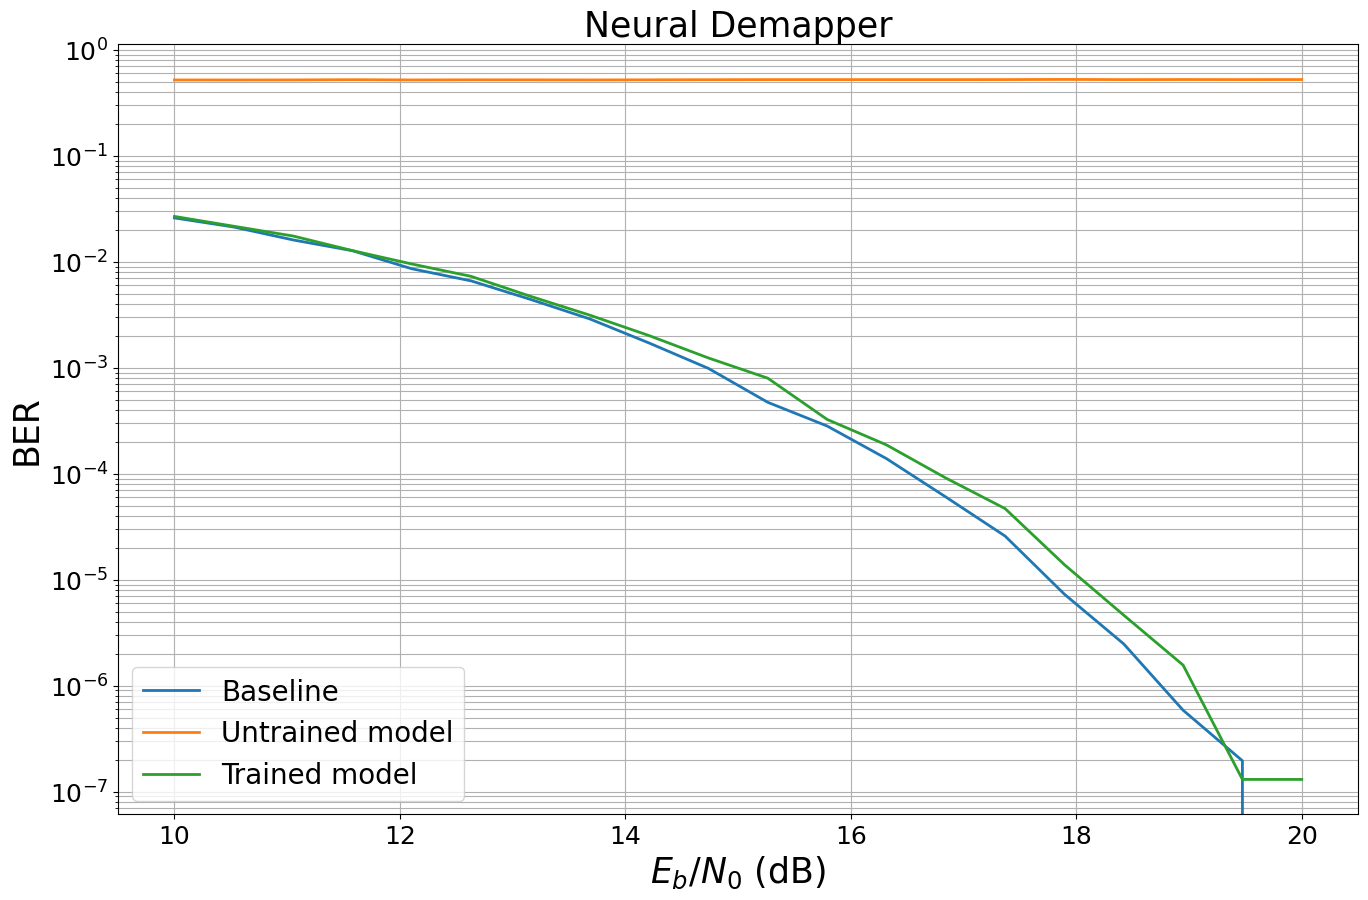

In [33]:
# Computing and plotting BER
ber_plots.simulate(model,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100,
                  legend="Trained model",
                  soft_estimates=True,
                  max_mc_iter=100,
                  show_fig=True);